# Analyse contrail climate impact of 2019 European departures


**Goal:** Quantify contrail forcing from 2019 European flights using the dataset presented in Teoh et al. (2024)

**Analyses:**

* Contrail forcing by **month of year** and **hour of day**
* Number of **“big hit”** flights (major warming contrails) by day, airport, and FIR
* Total CO₂ and contrail forcing per departure airport/FIR



## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Read file with flight schedules + contrail information on a flight-by-flight level
df = pd.read_parquet(r"C:\Users\TE\Documents\Datasets\icl/2019 - Jet-A - Flight Summary.pq")


# Map countries to regions
countries = pd.read_csv("data/countries.csv")
iso2_to_region = countries.set_index('alpha-2')['region'].to_dict()
df['origin_region'] = df['origin_country'].map(iso2_to_region)

# Filter European departures only since the file also contains incoming flights
df = df[df["origin_region"] == "Europe"]

# Density of conventional jet fuel
density_kerosene = 0.81 # kg/l

# CO2 emitted per kilogram of jet fuel
CO2_per_kg_fuel  = 3.168  # kg_CO2/kg_jet_a1

# Total surface area of Earth
earth_surface_area = 5.101e14  # m^2

# CO2 absolute global warming potential over 20 years
CO2_agwp_20_years  = 2.39e-14  # yr W m^-2 kg^-2

# CO2 absolute global warming potential over 100 years
CO2_agwp_100_years = 8.8e-14  # yr W m^-2 kg^-2

# Number of seconds in a year
seconds_per_year   = 365 * 24 * 60 * 60  # s/yr

# Effective radiative forcing to radiative forcing ratio
ERF_RF_ratio = 0.42

# Conversion factors to convert fuel burn to forcing through CO2
fuel_to_co2_forcing_20  = CO2_per_kg_fuel * earth_surface_area * CO2_agwp_20_years  * seconds_per_year
fuel_to_co2_forcing_100 = CO2_per_kg_fuel * earth_surface_area * CO2_agwp_100_years * seconds_per_year

def attach_gwp_from_fuel_burn(df): 
    # Calculate tailpipe CO2 emissions, AGWP and GWP
    df["total_co2"]              = df["total_fuel_burn"] * CO2_per_kg_fuel
    df["total_co2_forcing_20"]   = df["total_fuel_burn"] * fuel_to_co2_forcing_20
    df["total_co2_forcing_100"]  = df["total_fuel_burn"] * fuel_to_co2_forcing_100
    df["gwp20"]                  = df["total_contrail_energy_forcing"] / df["total_co2_forcing_20"]   * ERF_RF_ratio
    df["gwp100"]                 = df["total_contrail_energy_forcing"] / df["total_co2_forcing_100"]  * ERF_RF_ratio
    df["total_contrail_gwp20"]   = df["total_co2"] * df["gwp20"]
    df["total_contrail_gwp100"]  = df["total_co2"] * df["gwp100"]

# Compute GWP20/GWP100 for df
attach_gwp_from_fuel_burn(df)


# Attach one of the labels "Cooling", "No contrail", "Big hit" or "Other warming" to every flight
def label_by_contrail_warming(df, big_hit_threshold = 0.8): 
    # Compute which flights generate 80% of total contrail warming
    sorted_df   = df.sort_values(by="total_contrail_energy_forcing", ascending=False)
    cumulative  = sorted_df["total_contrail_energy_forcing"].cumsum()
    normalized  = cumulative / cumulative.iloc[-1]
    # Entries in normalized indicated which warming percentile a given flight is at
    eighty_idx  = (normalized >= big_hit_threshold).to_numpy().argmax()
    big_hits    = sorted_df.iloc[:eighty_idx]
    big_hit_ids = big_hits["flight_id"].unique().tolist()

    # Assign warming types
    df["warming_type"] = np.where(df["mean_contrail_lifetime"].isna(), "No contrail", "Other warming")
    df.loc[df["total_contrail_energy_forcing"] < 0, "warming_type"] = "Cooling"
    df.loc[df["flight_id"].isin(big_hit_ids), "warming_type"] = "Big hit"

    # Create indicator columns for better performance
    df = df.assign(
    is_big_hit    =(df["warming_type"] == "Big hit").astype(int),
    is_warming    =(df["warming_type"] == "Warming").astype(int),
    is_cooling    =(df["warming_type"] == "Cooling").astype(int),
    is_no_contrail=(df["warming_type"] == "No contrail").astype(int)
    )


label_by_contrail_warming(df)

# Create indicator columns for better performance
df = df.assign(
is_big_hit     = (df["warming_type"] == "Big hit").astype(int),
is_warming     = (df["warming_type"] == "Warming").astype(int),
is_cooling     = (df["warming_type"] == "Cooling").astype(int),
is_no_contrail = (df["warming_type"] == "No contrail").astype(int)
)

# Add months and hours for grouping operations
df["time"]   = pd.to_datetime(df["first_waypoint_time" ], errors="coerce")
df["date"]   = df["time"].dt.date
df["month"]  = df["time"].dt.month
df["hour"]   = df["time"].dt.hour




## 1. Statements

5% of flights generated 80% of contrail warming from European departures in 2019.  

In [7]:
len(df[df["warming_type"] == "Big hit"])/len(df)

0.04411520491135906

Average distance of European departure

In [8]:
df["total_flight_distance_km"].mean()

np.float64(1655.454338263187)

Average distance of big hit flight

In [9]:
df[df["warming_type"] == "Big hit"]["total_flight_distance_km"].mean()

np.float64(4190.129881003184)

Minimum forcing of big hit flight?

In [10]:
df[df["warming_type"] == "Big hit"]["total_contrail_energy_forcing"].min() /1e14

np.float64(2.858121681361797)

In [13]:
df[df["warming_type"] == "Big hit"]["total_contrail_gwp20"].min()/1e3

np.float64(312.22679671238)

In [14]:
df[df["warming_type"] == "Big hit"]["total_contrail_gwp100"].min()/1e3

np.float64(84.79795956165776)

Average big hit contrail length?

In [21]:
df[df["warming_type"] == "Big hit"]["total_persistent_contrail_length_km"].mean()

np.float64(1191.7912367203337)

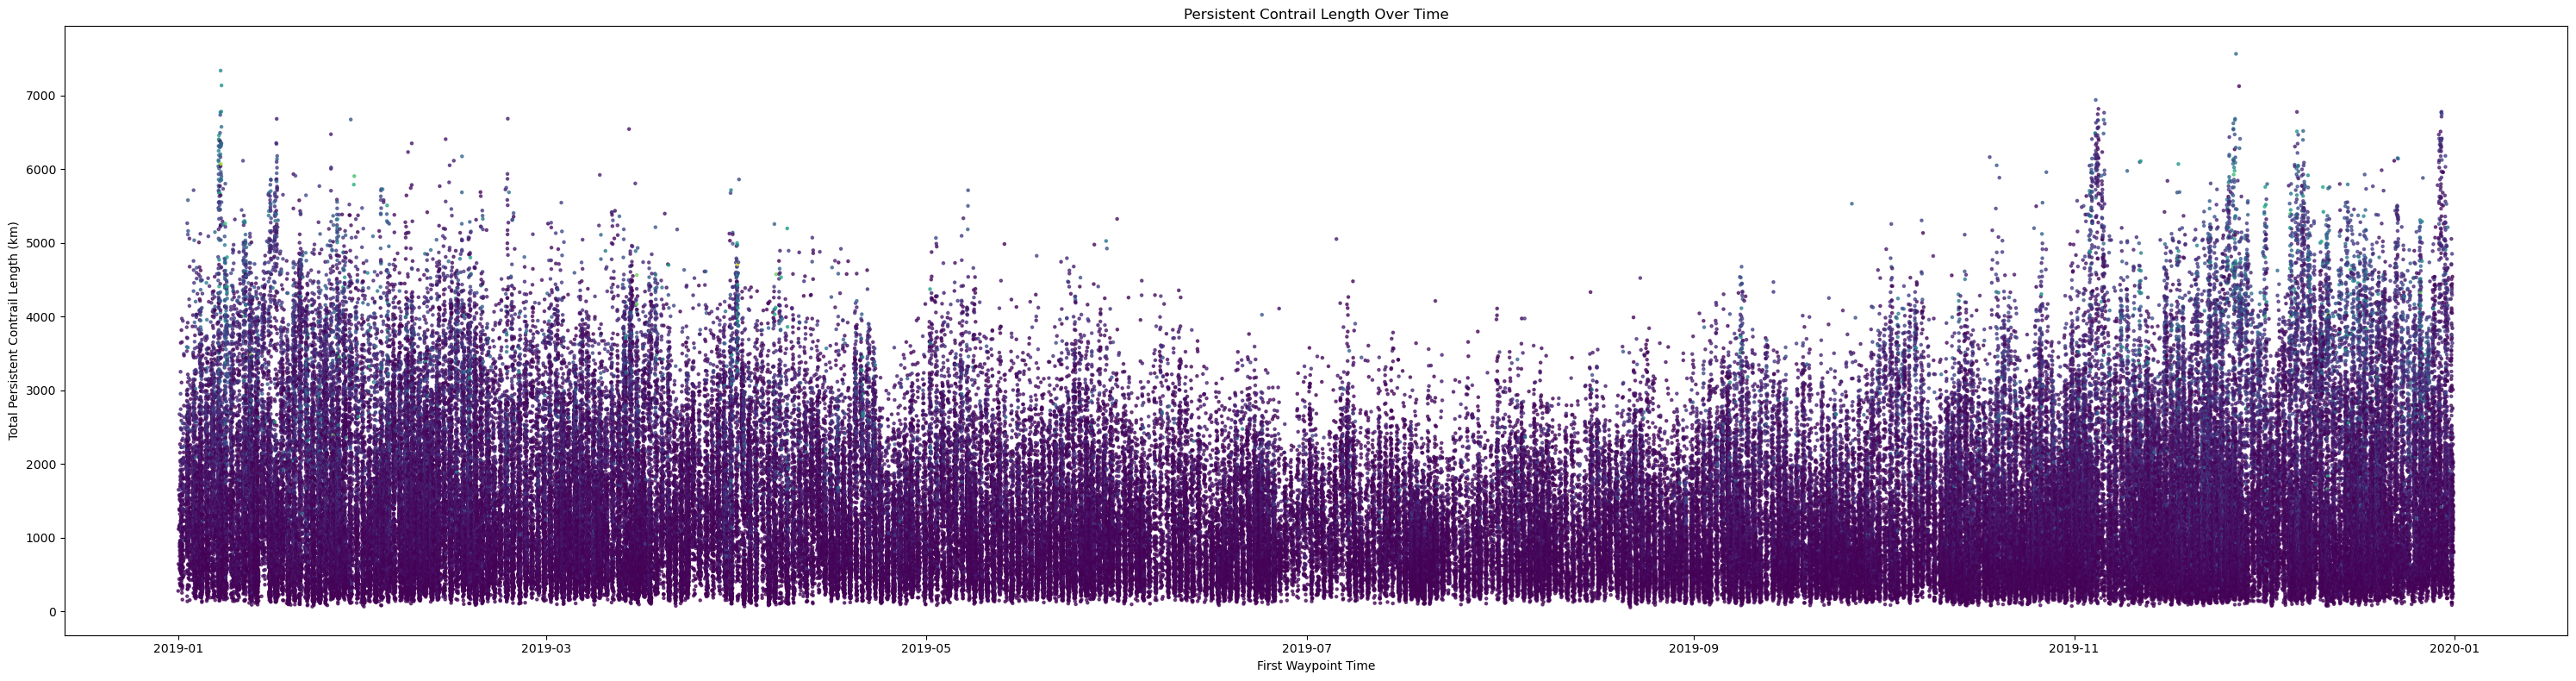

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure your time column is datetime
df['first_waypoint_time'] = pd.to_datetime(df['first_waypoint_time'])

big_hits = df[df["warming_type"] == "Big hit"]
# Sort by time so the timeline is consistent
big_hits = big_hits.sort_values('first_waypoint_time')

# Create the scatter plot
plt.figure(figsize=(30, 8))

scatter = plt.scatter(
    big_hits['first_waypoint_time'],
    big_hits['total_persistent_contrail_length_km'],
    c=big_hits["total_contrail_gwp100"],  # convert to numeric colour levels
    cmap='viridis',
    alpha=0.7,
    s=5
)

# Create a legend mapping codes back to labels
plt.title("Persistent Contrail Length Over Time")
plt.xlabel("First Waypoint Time")
plt.ylabel("Total Persistent Contrail Length (km)")
plt.tight_layout()
plt.show()


## 2. Compute contrail forcing by departure month and hour for European departures

In [ ]:
MONTHS = range(1, 13)
HOURS = range(24)

def aggregate_contrail_forcing(df, group_col):

    # --- Aggregate total forcing ---
    forcing = (
        df.groupby([group_col, "warming_type"], dropna=True)
          ["total_contrail_energy_forcing"]
          .sum()
          .unstack(fill_value=0)
    )

    # --- Count number of flights ---
    flights = (
        df.groupby([group_col, "warming_type"], dropna=True)
          .size()
          .unstack(fill_value=0)
          .add_suffix("_flights")
    )

    # --- Combine both ---
    result = pd.concat([forcing, flights], axis=1).reset_index()

    return result

In [41]:
# Aggregate by month
monthly = aggregate_contrail_forcing(df, "month")

# Step 1. Rename columns neatly for visualization
monthly = monthly.rename(columns={
    "warming_type": "Warming Type",
    "month": "Month",
    "Big hit": "Big hit warming",
    "Cooling": "Cooling",
    "No contrail": "No contrail",
    "Other warming": "Other warming",
    "Big hit_flights": "Big Hit Flights",
    "Cooling_flights": "Cooling Flights",
    "No contrail_flights": "No Contrail Flights",
    "Other warming_flights": "Other Warming Flights"
})

# Step 2. Map month numbers (1–12) to month names
month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}
monthly["Month"] = monthly["Month"].map(month_map)

# Step 3. Add total columns
monthly["Total warming"] = (
    monthly["Big hit warming"] +
    monthly["Cooling"] +
    monthly["No contrail"] +
    monthly["Other warming"]
)

monthly["Total number of flights"] = (
    monthly["Big Hit Flights"] +
    monthly["Cooling Flights"] +
    monthly["No Contrail Flights"] +
    monthly["Other Warming Flights"]
)


# Step 4. Select and reorder columns for visualization
cols_to_keep = [
    "Month",
    "Total number of flights",          # normalized version of Total Flights
    "Big hit warming",        # normalized Big Hit Warming
    "Other warming",          # normalized Other Warming
    "Cooling"                 # normalized Cooling
]


normalized = monthly[cols_to_keep].copy()
normalized["Total number of flights"] /= (1/100) * monthly["Total number of flights"].sum()
normalized["Big hit warming"]         /= (1/100) * monthly["Total warming"].sum()
normalized["Other warming"]           /= (1/100) * monthly["Total warming"].sum()
normalized["Cooling"]                 /= (1/100) * monthly["Total warming"].sum()

normalized = normalized.round(1)

# Export to CSV
normalized.to_csv("output/departures/1_big_hits_by_month.csv", index=False)

![image.png](figures\1_departures\departures_1_traffic_by_month@2x.png)

In [ ]:

# Aggregate by hour
hourly = aggregate_contrail_forcing(df, "hour")


# Step 1. Rename columns neatly for visualization
hourly = hourly.rename(columns={
    "warming_type": "Warming Type",
    "hour": "Hour",
    "Big hit": "Big hit warming",
    "Cooling": "Cooling",
    "No contrail": "No contrail",
    "Other warming": "Other warming",
    "Big hit_flights": "Big Hit Flights",
    "Cooling_flights": "Cooling Flights",
    "No contrail_flights": "No Contrail Flights",
    "Other warming_flights": "Other Warming Flights"
})

# Step 2. Add total columns
hourly["Total warming"] = (
    hourly["Big hit warming"] +
    hourly["Cooling"] +
    hourly["No contrail"] +
    hourly["Other warming"]
)

hourly["Total number of flights"] = (
    hourly["Big Hit Flights"] +
    hourly["Cooling Flights"] +
    hourly["No Contrail Flights"] +
    hourly["Other Warming Flights"]
)


# Step 3. Select and reorder columns for visualization
cols_to_keep = [
    "Hour",
    "Total number of flights",          # normalized version of Total Flights
    "Big hit warming",        # normalized Big Hit Warming
    "Other warming",          # normalized Other Warming
    "Cooling"                 # normalized Cooling
]


normalized = hourly[cols_to_keep].copy()
normalized["Total number of flights"] /= (1/100) * hourly["Total number of flights"].sum()
normalized["Big hit warming"]         /= (1/100) * hourly["Total warming"].sum()
normalized["Other warming"]           /= (1/100) * hourly["Total warming"].sum()
normalized["Cooling"]                 /= (1/100) * hourly["Total warming"].sum()
normalized = normalized.round(1)

# Export to CSV
normalized.to_csv("output/departures/2_big_hits_by_hour.csv", index=False)

![image.png](figures\1_departures\departures_2_traffic_by_hour@2x.png)

## 3. Big hits by day and airport

In [5]:
df.head()

,flight_id,aircraft_type_icao,aircraft_engine_type,origin_airport,origin_airport_name,origin_country,destination_airport,destination_airport_name,destination_country,first_waypoint_time,...,warming_type,is_big_hit,is_warming,is_cooling,is_no_contrail,time,date,month,hour,origin_region
8,190101-10273-TAP005,A343,Jet,LPPT,Humberto Delgado Airport (Lisbon Portela Airport),PT,SBSG,São Gonçalo do Amarante - Governador Aluízio A...,BR,2019-01-01 00:14:31.000,...,No contrail,0,0,0,1,2019-01-01 00:14:31.000,2019-01-01,1,0,Europe
453,190101-15431-CCA722,A332,Jet,LHBP,Budapest Liszt Ferenc International Airport,HU,ZBAA,Beijing Capital International Airport,CN,2019-01-01 00:01:57.000,...,No contrail,0,0,0,1,2019-01-01 00:01:57.000,2019-01-01,1,0,Europe
1163,190101-2240-IBE2601,A332,Jet,LEBL,Josep Tarradellas Barcelona-El Prat Airport,ES,SAEZ,Ministro Pistarini International Airport,AR,2019-01-01 00:31:09.545,...,No contrail,0,0,0,1,2019-01-01 00:31:09.545,2019-01-01,1,0,Europe
1387,190101-2558-AFR6744,B77L,Jet,LFPG,Charles de Gaulle International Airport,FR,DRRN,Diori Hamani International Airport,NE,2019-01-01 00:01:45.000,...,No contrail,0,0,0,1,2019-01-01 00:01:45.000,2019-01-01,1,0,Europe
1601,190101-28265-ETD88F,B77W,Jet,EDDM,Munich Airport,DE,OMAA,Abu Dhabi International Airport,AE,2019-01-01 00:39:21.000,...,No contrail,0,0,0,1,2019-01-01 00:39:21.000,2019-01-01,1,0,Europe


In [ ]:
import pandas as pd

# Load airports data
airports = pd.read_csv("data/airports.csv")

# Keep only the needed columns and rename for clarity
airports = airports.rename(columns={
    "icao": "origin_airport",
    "latitude": "origin_latitude",
    "longitude": "origin_longitude"
})[["origin_airport", "origin_latitude", "origin_longitude"]]

# Merge with the flights DataFrame on origin_airport
df = df.merge(airports, on="origin_airport", how="left")


df

,flight_id,aircraft_type_icao,aircraft_engine_type,origin_airport,origin_airport_name,origin_country,destination_airport,destination_airport_name,destination_country,first_waypoint_time,...,is_warming,is_cooling,is_no_contrail,time,date,month,hour,origin_region,origin_latitude,origin_longitude
0,190101-10273-TAP005,A343,Jet,LPPT,Humberto Delgado Airport (Lisbon Portela Airport),PT,SBSG,São Gonçalo do Amarante - Governador Aluízio A...,BR,2019-01-01 00:14:31.000,...,0,0,1,2019-01-01 00:14:31.000,2019-01-01,1,0,Europe,38.781300,-9.135920
1,190101-15431-CCA722,A332,Jet,LHBP,Budapest Liszt Ferenc International Airport,HU,ZBAA,Beijing Capital International Airport,CN,2019-01-01 00:01:57.000,...,0,0,1,2019-01-01 00:01:57.000,2019-01-01,1,0,Europe,47.429760,19.261093
2,190101-2240-IBE2601,A332,Jet,LEBL,Josep Tarradellas Barcelona-El Prat Airport,ES,SAEZ,Ministro Pistarini International Airport,AR,2019-01-01 00:31:09.545,...,0,0,1,2019-01-01 00:31:09.545,2019-01-01,1,0,Europe,41.297100,2.078460
3,190101-2558-AFR6744,B77L,Jet,LFPG,Charles de Gaulle International Airport,FR,DRRN,Diori Hamani International Airport,NE,2019-01-01 00:01:45.000,...,0,0,1,2019-01-01 00:01:45.000,2019-01-01,1,0,Europe,49.012798,2.550000
4,190101-28265-ETD88F,B77W,Jet,EDDM,Munich Airport,DE,OMAA,Abu Dhabi International Airport,AE,2019-01-01 00:39:21.000,...,0,0,1,2019-01-01 00:39:21.000,2019-01-01,1,0,Europe,48.353802,11.786100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7436796,200101-1202-AEA025,A332,Jet,LEMD,Adolfo Suárez Madrid–Barajas Airport,ES,SLVR,Viru Viru International Airport,BO,2019-12-31 23:41:50.000,...,0,0,0,2019-12-31 23:41:50.000,2019-12-31,12,23,Europe,40.471926,-3.562640
7436797,200101-1489-AEA041,B789,Jet,LEMD,Adolfo Suárez Madrid–Barajas Airport,ES,SAEZ,Ministro Pistarini International Airport,AR,2019-12-31 23:39:57.000,...,0,0,0,2019-12-31 23:39:57.000,2019-12-31,12,23,Europe,40.471926,-3.562640
7436798,200101-1681-AFR470,B77W,Jet,LFPG,Charles de Gaulle International Airport,FR,FIMP,Sir Seewoosagur Ramgoolam International Airport,MU,2019-12-31 23:59:07.000,...,0,0,1,2019-12-31 23:59:07.000,2019-12-31,12,23,Europe,49.012798,2.550000
7436799,200101-28984-AMX008,B788,Jet,EGLL,London Heathrow Airport,GB,MMMX,Licenciado Benito Juarez International Airport,MX,2019-12-31 23:23:25.000,...,0,0,0,2019-12-31 23:23:25.000,2019-12-31,12,23,Europe,51.470600,-0.461941


In [30]:
df = df[df["origin_country"] != "RU"]

In [31]:


# Aggregate by date and FIR
airport_daily_full = (
    df.groupby(["date", "origin_airport_name", "origin_latitude", "origin_longitude"], as_index=False)
    .agg(
        n_total=("flight_id", "count"),
        n_big_hit=("is_big_hit", "sum"),
        n_warming=("is_warming", "sum"),
        n_cooling=("is_cooling", "sum"),
        n_no_contrail=("is_no_contrail", "sum"),
        total_contrail_energy_forcing=("total_contrail_energy_forcing", "sum"),
        total_fuel_burn=("total_fuel_burn", "sum"),
    )
)


# --- 1️⃣ Find top 10 airports by total fuel burn ---
# Storing the daily data for all airports results in a very big file
top_airports = (
    df.groupby("origin_airport_name", as_index=False)["total_fuel_burn"]
      .sum()
      .nlargest(3, "total_fuel_burn")["origin_airport_name"]
)

# --- 2️⃣ Filter the dataframe ---
airport_daily_simple = airport_daily_full[airport_daily_full["origin_airport_name"].isin(top_airports)]


airport_daily_simple = airport_daily_simple[[
    "date", "origin_airport_name", "n_big_hit"
]].rename(columns={"date": "Date", "origin_airport_name": "Departure airport", "n_big_hit": "Number of big hits"})


airport_daily_simple.to_csv("output/departures/3_daily_big_hits_by_airport.csv", index=False)


![image.png](figures\1_departures\departures_3_big_hits_per_day_airport@2x.png)

## 4. Warming by airport

In [32]:

# Sum across days by FIR
airport_totals = (
    airport_daily_full.groupby(["origin_airport_name", "origin_latitude", "origin_longitude"], as_index=False)
    .agg(
        n_total=("n_total", "sum"),
        n_big_hit=("n_big_hit", "sum"),
        n_warming=("n_warming", "sum"),
        n_cooling=("n_cooling", "sum"),
        n_no_contrail=("n_no_contrail", "sum"),
        total_contrail_energy_forcing=("total_contrail_energy_forcing", "sum"),
        total_fuel_burn=("total_fuel_burn", "sum"),
    )
)
attach_gwp_from_fuel_burn(airport_totals)

# --- Rename columns for readability ---
airport_totals = airport_totals.rename(columns={
    "origin_airport_name": "Airport",
    "origin_latitude": "Latitude",
    "origin_longitude": "Longitude",
    "n_total": "Flights Total",
    "n_big_hit": "Flights Big Hit",
    "n_warming": "Flights Warming",
    "n_cooling": "Flights Cooling",
    "n_no_contrail": "Flights No Contrail",
    "total_contrail_energy_forcing": "Contrail Forcing (10^18 J)",
    "total_fuel_burn": "Fuel Burn (t)",
    "total_co2": "CO2 (Mt)",
    "total_co2_forcing_20": "CO2 Forcing 20yr (10^18 J)",
    "total_co2_forcing_100": "CO2 Forcing 100yr (10^18 J)",
    "gwp20": "GWP20",
    "gwp100": "GWP100",
    "total_contrail_gwp20": "Contrail CO2eq 20yr (Mt)",
    "total_contrail_gwp100": "Contrail CO2eq 100yr (Mt)"
})

# --- Convert units ---
# Convert kg → Mt and J → 10^18 J
airport_totals["CO2 (Mt)"] /= 1e9
airport_totals["Contrail CO2eq 20yr (Mt)"] /= 1e9
airport_totals["Contrail CO2eq 100yr (Mt)"] /= 1e9

airport_totals["Contrail Forcing (10^18 J)"] /= 1e18
airport_totals["CO2 Forcing 20yr (10^18 J)"] /= 1e18
airport_totals["CO2 Forcing 100yr (10^18 J)"] /= 1e18
# --- Save the clean dataset ---
airport_totals.to_csv("output/departures/4_warming_by_airport.csv", index=False)

![image.png](figures\1_departures\departures_4_airports@2x.png)

## 5. Big hits by day and FIR

In [ ]:
import json
import geopandas as gpd, topojson

# Load flight information region boundaries 
with open(r"data/worldfirs.json") as f:
    topo = json.load(f)

gdf = (
    topojson.Topology(topo, object_name="data")
        .to_gdf()
        .set_crs(4326)           # WGS-84
)

# Filter only FIRs (and not so-called upper information regions (UIRs))
gdf = gdf[gdf["type"].str.contains("FIR")]

# Filter out European FIRs
european_fir = pd.read_csv("data/european_firs.csv")
gdf = gdf[gdf["designator"].isin(european_fir["FIR code"])]

# Load airports
airports = pd.read_csv("data/airports.csv")

# Keep only the needed columns and rename for clarity
airports = airports.rename(columns={
    "icao": "origin_airport",
})

# Convert airports DataFrame to GeoDataFrame
airports_gdf = gpd.GeoDataFrame(
    airports,
    geometry=gpd.points_from_xy(airports.longitude, airports.latitude),
    crs="EPSG:4326"  # WGS84
)

# Match each airport to its FIR polygon
airports_with_fir = gpd.sjoin(
    airports_gdf,
    gdf[["geometry", "designator", "name"]],
    how="left",
    predicate="within"
)

# Rename columns for clarity
airports_with_fir = airports_with_fir.rename(columns={
    "designator": "fir_code",
    "name_right": "fir_name"
})

# Make sure FIRs are attached
df_europe = df.merge(
    airports_with_fir[["origin_airport", "fir_code", "fir_name"]],
    on="origin_airport",
    how="left"
)

# Aggregate by date and FIR
fir_daily_full = (
    df_europe.groupby(["date", "fir_code", "fir_name"], as_index=False)
    .agg(
        n_total=("flight_id", "count"),
        n_big_hit=("is_big_hit", "sum"),
        n_warming=("is_warming", "sum"),
        n_cooling=("is_cooling", "sum"),
        n_no_contrail=("is_no_contrail", "sum"),
        total_contrail_energy_forcing=("total_contrail_energy_forcing", "sum"),
        total_fuel_burn=("total_fuel_burn", "sum"),
    )
)

fir_daily_simple = fir_daily_full[[
    "date", "fir_code", "fir_name", "n_big_hit"
]].rename(columns={"date": "Date", "fir_code": "FIR code", "fir_name": "FIR", "n_big_hit": "Number of big hit departures"})

fir_daily_simple.to_csv("output/departures/5_daily_big_hits_by_fir.csv", index=False)

                                            geometry designator type  upper  \
0  POLYGON ((159.0001 -4.83327, 156.03334 -6.5499...       AGGG  FIR    NaN   
1  POLYGON ((160.00018 9.00001e-5, 160.00018 -1.4...       ANAU  FIR    NaN   
2  POLYGON ((141.00008 9.00001e-5, 141.00008 -2.5...       AYPM  FIR    NaN   
3  POLYGON ((-60 90, -60 86.99994, -60 84.99995, ...       BGGL  FIR    NaN   
4  POLYGON ((-5.49991 60.99999, -5.14639 60.99999...       BIRD  FIR    NaN   

   lower              name  
0    0.0       Honiara FIR  
1    0.0         Nauru FIR  
2    0.0  Port Moresby FIR  
3    0.0          Nuuk FIR  
4    0.0     Reykjavik FIR  
                                             geometry designator type  upper  \
4   POLYGON ((-5.49991 60.99999, -5.14639 60.99999...       BIRD  FIR    NaN   
20  POLYGON ((3.0069 51.40526, 2.50002 51.45548, 2...       EBBU  FIR  195.0   
22  POLYGON ((9.62443 48.62138, 9.68635 48.6986, 9...       EDGG  FIR  245.0   
23  POLYGON ((9.54991 47.83334,

![image.png](figures\1_departures\departures_5_big_hits_per_day_fir@2x.png)

## 6. Warming by FIR

In [ ]:

# Sum across days by FIR
fir_totals = (
    fir_daily_full.groupby(["fir_code", "fir_name"], as_index=False)
    .agg(
        n_total=("n_total", "sum"),
        n_big_hit=("n_big_hit", "sum"),
        n_warming=("n_warming", "sum"),
        n_cooling=("n_cooling", "sum"),
        n_no_contrail=("n_no_contrail", "sum"),
        total_contrail_energy_forcing=("total_contrail_energy_forcing", "sum"),
        total_fuel_burn=("total_fuel_burn", "sum"),
    )
)
attach_gwp_from_fuel_burn(fir_totals)
fir_totals.to_csv("output/departures/6_warming_by_fir.csv", index=False)

![image.png](figures\1_departures\departures_6_big_hits_by_fir@2x.png)

## 7. Flight distance band

In [4]:
import pandas as pd
import numpy as np

df = df[df["origin_region"] == "Europe"]

# Define the flight distance bins (0–500, 500–1000, etc.)
bins = np.arange(0, df["total_flight_distance_km"].max() + 1000, 1000)
labels = [f"{bins[i]:.0f}-{bins[i+1]:.0f} km" for i in range(len(bins)-1)]

# Categorize flights into bands
df["distance_band"]  = pd.cut(df["total_flight_distance_km"], bins=bins, labels=labels, right=False)
# Aggregate total CO2 and total_contrail_gwp20 by distance band
agg_df = (
    df.groupby("distance_band", observed=True)
      .agg(
          total_co2_sum=("total_co2", "sum"),
          total_contrail_gwp20_sum=("total_contrail_gwp20", "sum"),
          n_flights=("flight_id", "count"),
          dist_sum=("total_flight_distance_km", "sum")
      )
      .reset_index()
)

agg_df["gwp_20_ratio"] = agg_df["total_contrail_gwp20_sum"]/agg_df["total_co2_sum"]

agg_df["co2_per_dist"]   = agg_df["total_co2_sum"] / agg_df["dist_sum"]
agg_df["gwp20_per_dist"] = agg_df["total_contrail_gwp20_sum"] / agg_df["dist_sum"]

# Rename columns for clarity
agg_df = agg_df.rename(columns={
    "distance_band": "Flight distance band (km)",
    "total_co2_sum": "Tailpipe CO₂",
    "total_contrail_gwp20_sum": "Contrail warming",
    "dist_sum": "Total flight distance (km)",
    "n_flights": "Number of flights",
    "gwp_20_ratio": "Contrails to CO₂ ratio",
    "co2_per_dist": "Tailpipe CO₂ per flight distance",
    "gwp20_per_dist": "Contrail warming per flight distance"
})

# Sort and save
agg_df = agg_df.sort_values("Flight distance band (km)").reset_index(drop=True)
agg_df.to_csv("output/departures/7_warming_by_distance.csv", index=False)

![image.png](figures\1_departures\departures_7_by_distance@2x.png)

## 8. Warming by aircraft type

In [8]:
import pandas as pd
import numpy as np

# -----------------------------------------------------
# 1. Aircraft classification dictionary
# -----------------------------------------------------

wide_body = [
    "A332","A333","A338","A339","A342","A343","A345","A346",
    "A359","A35K",
    "A388","A380",
    "B742","B743","B744","B748",
    "B772","B77L","B77W","B773",
    "B764","B763","B762",
    "B787","B788","B789","B78X",
    "IL96","DC10","MD11"
]

narrow_body = [
    "A318","A319","A320","A320N","A20N","A321","A21N","A310",
    "A319","A320","A321","A19N",
    "B737","B733","B734","B735","B736","B738","B739","B38M","B37M","B39M",
    "B712","B752","B753",
    "MD82","MD83","MD88"
]

regional = [
    "E170","E175","E190","E195","E290","E295",
    "CRJ1","CRJ2","CRJ7","CRJ9","CRJX",
    "AT45","AT46","AT72","AT75","AT76","AT43",
    "DH8A","DH8B","DH8C","DH8D","D328","DHC6",
    "SF34","F70","F100","RJ70","RJ85","RJ1H"
]

cargo = [
    "B744F","BLCF","AN12","AN22","AN26","AN30","A124","A400",
    "C130","C160","C295","IL76","C5M","K35R","DC3T","CVLT"
]

business = [
    # Business jets (Cessna Citation series, Gulfstream, Learjet etc)
    "C25A","C25B","C25C","C25M","C510","C525","C550","C551","C560","C650","C680","C68A","C700","C750",
    "CL30","CL35","CL60",
    "GLF2","GLF3","GLF4","GLF5","GLF6","GL5T","G280","G150","GLEX","GA5C",
    "LJ31","LJ35","LJ40","LJ45","LJ55","LJ60","LJ75",
    "FA7X","FA8X","FA10","FA20","FA50",
]

general_aviation = [
    # Small turboprops and GA aircraft (Pilatus, Piper, Beechcraft, etc.)
    "PC12","PC24","PC6T","PC21","P06T","PA32","PA34","PA44","PA46","PA28A","PA28R","PA28T","PA31","PA38",
    "BE20","BE33","BE35","BE36","BE40","BE55","BE58","BE60","BE76","BE9L","BE9T","BE99",
    "C172","C182","C206","C207","C340","C402","C414","C421",
    "SR20","SR22","TBM7","TBM8","TBM9",

    # Military trainers, gliders, and misc
    "F16","F18H","EUFI","T28","T33","B52","M20P"
]

# Build dictionary
aircraft_classification = {}

for t in wide_body:
    aircraft_classification[t] = "Wide-body"

for t in narrow_body:
    aircraft_classification[t] = "Narrow-body"

for t in regional:
    aircraft_classification[t] = "Regional"

for t in cargo:
    aircraft_classification[t] = "Cargo / Freighter"

for t in business:
    aircraft_classification[t] = "Business"

for t in general_aviation:
    aircraft_classification[t] = "General Aviation"

# Default catch-all
def classify(a):
    return aircraft_classification.get(a, "Other / Unclassified")

df["aircraft_class"] = df["aircraft_type_icao"].apply(classify)


# -----------------------------------------------------
# 2. Compute aggregated metrics by aircraft_type_icao
# -----------------------------------------------------

agg_df = (
    df.groupby(["aircraft_class"], observed=True)
      .agg(
          total_co2_sum=("total_co2", "sum"),
          total_contrail_gwp20_sum=("total_contrail_gwp20", "sum"),
          n_flights=("flight_id", "count"),
          dist_sum=("total_flight_distance_km", "sum")
      )
      .reset_index()
)

# Ratios
agg_df["gwp_20_ratio"] = agg_df["total_contrail_gwp20_sum"] / agg_df["total_co2_sum"]
agg_df["co2_per_dist"]   = agg_df["total_co2_sum"] / agg_df["dist_sum"]
agg_df["gwp20_per_dist"] = agg_df["total_contrail_gwp20_sum"] / agg_df["dist_sum"]

# Rename
agg_df = agg_df.rename(columns={
    "total_co2_sum": "Tailpipe CO₂",
    "total_contrail_gwp20_sum": "Contrail warming",
    "dist_sum": "Total flight distance (km)",
    "n_flights": "Number of flights",
    "gwp_20_ratio": "Contrails to CO₂ ratio",
    "co2_per_dist": "Tailpipe CO₂ per flight distance",
    "gwp20_per_dist": "Contrail warming per flight distance"
})

agg_df = agg_df.sort_values(["aircraft_class"])

# Save
agg_df.to_csv("output/departures/8_warming_by_aircraft_type.csv", index=False)

print("Saved to output/departures/aircraft_warming_metrics.csv")


Saved to output/departures/aircraft_warming_metrics.csv


![image.png](figures\1_departures\departures_8_by_aircraft@2x.png)